# Lab 4: TinyML – Quantization-Aware Training (QAT)

Aim: implement Quantization-Aware Training on a TinyML model using motion-sensor data recorded with the Phyphox app (Option A), and compare it with Post-Training Quantization (PTQ).

Objectives
1. Prepare input data from Phyphox sensor recordings.
2. Train a baseline model and apply full INT8 Post-Training Quantization.
3. Apply Quantization-Aware Training and convert the model to full INT8 TensorFlow Lite.
4. Compare the models in terms of accuracy, size and latency.

## Planned workflow

```
Phyphox recordings (circular, shake, still, walk)
        │  "Acceleration with g", 100 Hz, ~120 s each, exported as CSV
        ▼
Preprocessing
        │  label → time split (80/20) → 2 s windows (50% overlap) → z-score
        ▼
Baseline model (float32)  ──►  baseline_fp32.tflite
        │
        ├──────────────────────────────┐
        ▼                              ▼
PTQ: representative dataset     QAT: quantize_model + fine-tune
     → full INT8                     → full INT8
     ptq_int8.tflite                 qat_int8.tflite
        │                              │
        └──────────────┬───────────────┘
                       ▼
     Comparison: size (KB), accuracy (%), latency (ms)
                       ▼
               Questions and result
```

## 1. Lab setup

In [ ]:
!pip install -q tensorflow-model-optimization tf_keras
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
import tensorflow_model_optimization as tfmot

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")

keras = tf.keras
tf.get_logger().setLevel("ERROR")
keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
print("TensorFlow:", tf.__version__, "| tfmot:", tfmot.__version__)

TensorFlow: 2.21.0 | tfmot: 0.8.1


## 2. Input data (Option A – Phyphox)

Each class was recorded with the Phyphox "Acceleration with g" experiment on an iPhone, sampled at 100 Hz for about 2 minutes, and exported as CSV.
Place the four CSV files in a folder named `data` (in Colab: upload them and set `DATA_DIR`).

In [ ]:
DATA_DIR = "data"
CLASSES = ["circular", "shake", "still", "walk"]

raw = {}
for label, name in enumerate(CLASSES):
    df = pd.read_csv(os.path.join(DATA_DIR, f"{name}.csv"))
    df.columns = ["t", "ax", "ay", "az", "a_abs"]
    df["label"] = label
    raw[name] = df
    fs = 1 / np.median(np.diff(df["t"]))
    print(f"{name:9s} rows={len(df):6d}  duration={df['t'].iloc[-1]:6.1f} s  rate={fs:.0f} Hz")

raw["walk"].head()

circular  rows= 12203  duration= 122.1 s  rate=100 Hz
shake     rows= 12149  duration= 121.6 s  rate=100 Hz
still     rows= 12113  duration= 121.2 s  rate=100 Hz
walk      rows= 12217  duration= 122.3 s  rate=100 Hz


,t,ax,ay,az,a_abs,label
0,0.002494,1.037343,1.475332,8.981024,9.160321,3
1,0.012502,1.012644,1.483864,8.737331,8.920104,3
2,0.022509,1.007255,1.414409,8.650661,8.823211,3
3,0.032517,0.938548,1.395997,8.746611,8.906901,3
4,0.042524,0.811762,1.366957,8.967402,9.107241,3


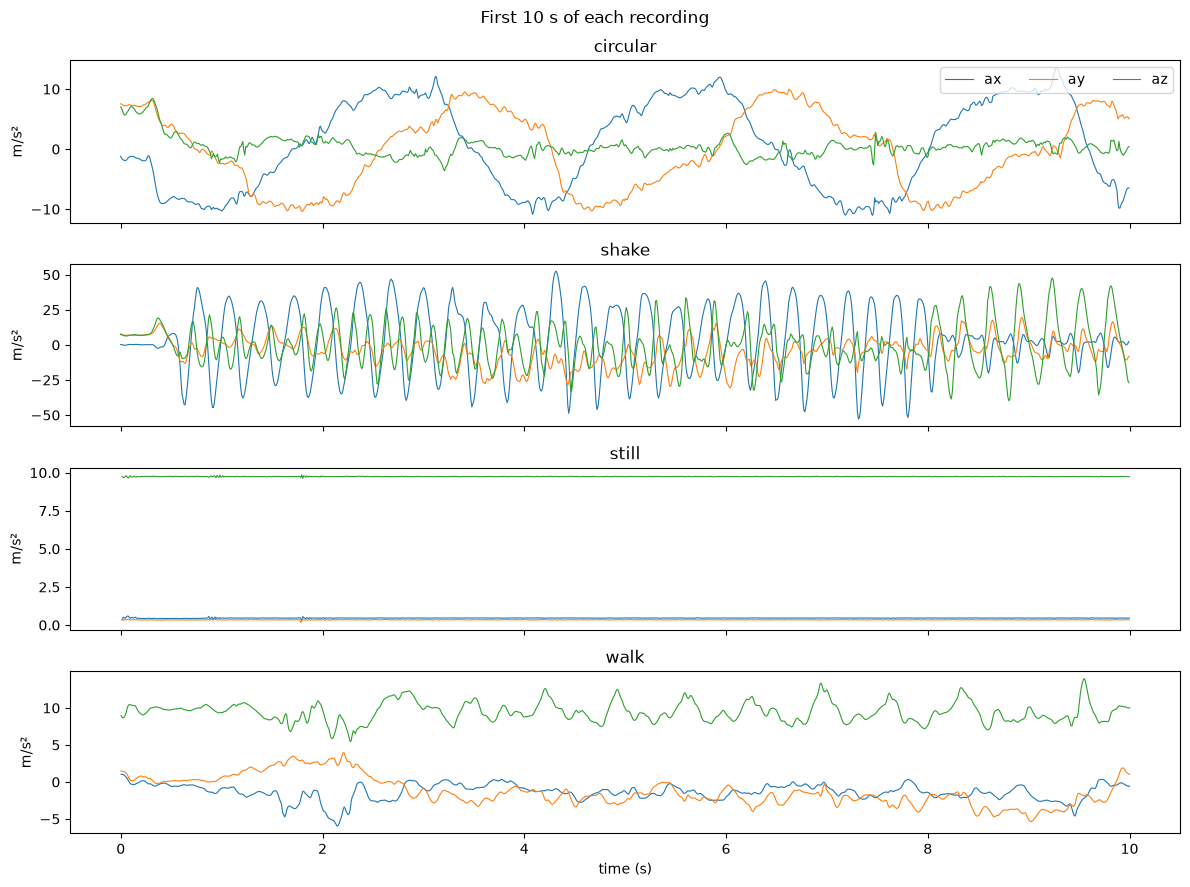

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, name in zip(axes, CLASSES):
    d = raw[name][raw[name]["t"] < 10]
    for col in ["ax", "ay", "az"]:
        ax.plot(d["t"], d[col], label=col, lw=0.8)
    ax.set_title(name); ax.set_ylabel("m/s²")
axes[0].legend(loc="upper right", ncol=3)
axes[-1].set_xlabel("time (s)")
plt.suptitle("First 10 s of each recording"); plt.tight_layout(); plt.show()

## 3. Preprocessing

Each recording is split by time (first 80% for training, last 20% for testing) before windowing, so overlapping windows never appear in both sets.
The signal is then cut into 2 s windows (200 samples) with 50% overlap and normalised with the training mean and standard deviation.

In [ ]:
WIN, STEP = 200, 100
TRAIN_FRAC = 0.8

def make_windows(arr):
    return np.array([arr[i:i + WIN] for i in range(0, len(arr) - WIN + 1, STEP)])

X_train, y_train, X_test, y_test = [], [], [], []
for label, name in enumerate(CLASSES):
    sig = raw[name][["ax", "ay", "az"]].values.astype("float32")
    cut = int(len(sig) * TRAIN_FRAC)
    w_tr, w_te = make_windows(sig[:cut]), make_windows(sig[cut:])
    X_train.append(w_tr); y_train += [label] * len(w_tr)
    X_test.append(w_te);  y_test  += [label] * len(w_te)

X_train, X_test = np.concatenate(X_train), np.concatenate(X_test)
y_train, y_test = np.array(y_train), np.array(y_test)


mean = X_train.mean(axis=(0, 1)); std = X_train.std(axis=(0, 1))
X_train = ((X_train - mean) / std).astype("float32")
X_test  = ((X_test  - mean) / std).astype("float32")


idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train windows per class:", np.bincount(y_train))
print("Test windows per class: ", np.bincount(y_test))

Train: (383, 200, 3)  Test: (92, 200, 3)
Train windows per class: [96 96 95 96]
Test windows per class:  [23 23 23 23]


## 4. Baseline model (float32)

A small CNN for TinyML. Conv1D is not supported by the tfmot QAT tool, so the window is reshaped to (200, 1, 3) and Conv2D with a (5, 1) kernel is used, which slides along time exactly like Conv1D.

In [ ]:
def build_model():
    return keras.Sequential([
        keras.layers.Input(shape=(WIN, 3)),
        keras.layers.Reshape((WIN, 1, 3)),
        keras.layers.Conv2D(16, (5, 1), activation="relu"),
        keras.layers.MaxPooling2D((2, 1)),
        keras.layers.Conv2D(32, (5, 1), activation="relu"),
        keras.layers.MaxPooling2D((2, 1)),
        keras.layers.Conv2D(32, (5, 1), activation="relu"),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(len(CLASSES), activation="softmax"),
    ])

baseline = build_model()
baseline.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 reshape (Reshape)           (None, 200, 1, 3)         0         


 conv2d (Conv2D)             (None, 196, 1, 16)        256       


...

 dense_1 (Dense)             (None, 4)                 132       


Total params: 9188 (35.89 KB)


Trainable params: 9188 (35.89 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


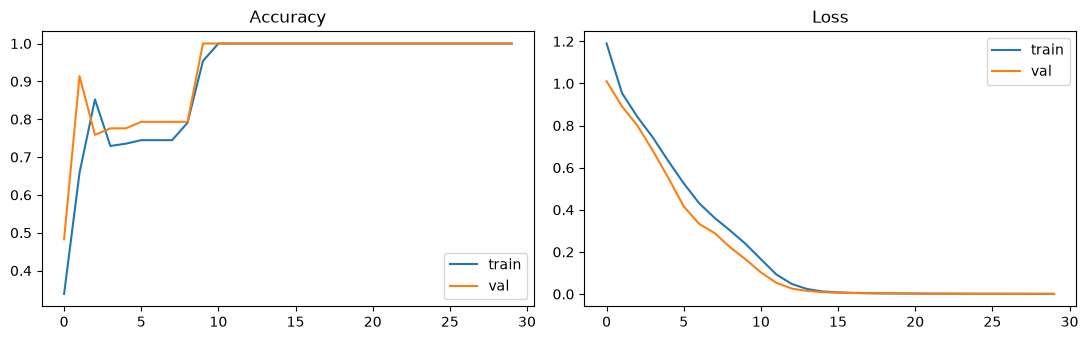

Baseline (Keras float32) test accuracy: 98.91%


In [ ]:
hist = baseline.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_split=0.15, verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist.history["accuracy"], label="train"); ax[0].plot(hist.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(hist.history["loss"], label="train"); ax[1].plot(hist.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].legend()
plt.tight_layout(); plt.show()

_, base_keras_acc = baseline.evaluate(X_test, y_test, verbose=0)
print(f"Baseline (Keras float32) test accuracy: {base_keras_acc*100:.2f}%")

In [ ]:
# export float32 baseline to TFLite
conv = tf.lite.TFLiteConverter.from_keras_model(baseline)
open("baseline_fp32.tflite", "wb").write(conv.convert())
print("Saved baseline_fp32.tflite")

Saved baseline_fp32.tflite


Helper functions to measure size, accuracy and latency of any `.tflite` model with the TFLite interpreter.

In [ ]:
def size_kb(path):
    return os.path.getsize(path) / 1024

def tflite_predict(path, X):
    interp = tf.lite.Interpreter(model_path=path); interp.allocate_tensors()
    inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
    preds = []
    for x in X:
        x = x[None]
        if inp["dtype"] == np.int8:
            s, z = inp["quantization"]
            x = np.clip(np.round(x / s + z), -128, 127)
        interp.set_tensor(inp["index"], x.astype(inp["dtype"]))
        interp.invoke()
        preds.append(np.argmax(interp.get_tensor(out["index"])[0]))
    return np.array(preds)

def tflite_accuracy(path):
    return 100 * np.mean(tflite_predict(path, X_test) == y_test)

def tflite_latency(path, runs=200):
    interp = tf.lite.Interpreter(model_path=path); interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    interp.set_tensor(inp["index"], np.zeros(inp["shape"], dtype=inp["dtype"]))
    for _ in range(10): interp.invoke()
    t0 = time.perf_counter()
    for _ in range(runs): interp.invoke()
    return (time.perf_counter() - t0) / runs * 1000

def tensor_types(path):
    interp = tf.lite.Interpreter(model_path=path); interp.allocate_tensors()
    inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
    return inp["dtype"].__name__, out["dtype"].__name__

print(f"Baseline TFLite accuracy: {tflite_accuracy('baseline_fp32.tflite'):.2f}%")

Baseline TFLite accuracy: 98.91%


## 5. Post-Training Quantization (full INT8)

The trained float32 model is converted after training. A representative dataset (100 training windows) is passed through the model so the converter can measure the range of every activation and pick INT8 scales.

In [ ]:
def representative_data():
    for i in range(100):
        yield [X_train[i:i + 1]]

conv = tf.lite.TFLiteConverter.from_keras_model(baseline)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_data
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
open("ptq_int8.tflite", "wb").write(conv.convert())

print("Input/output types:", tensor_types("ptq_int8.tflite"))
print(f"PTQ INT8 test accuracy: {tflite_accuracy('ptq_int8.tflite'):.2f}%")

Input/output types: ('int8', 'int8')
PTQ INT8 test accuracy: 98.91%


## 6. Quantization-Aware Training

`quantize_model` wraps the trained baseline with fake-quantization nodes that round weights and activations to INT8 in the forward pass. The model is then fine-tuned for a few epochs at a low learning rate so the weights adapt to the rounding.

QAT (Keras, fake-quant) test accuracy: 98.91%


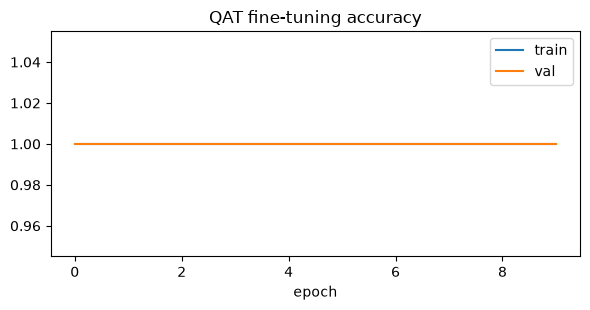

In [ ]:
qat_model = tfmot.quantization.keras.quantize_model(baseline)
qat_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

qat_hist = qat_model.fit(X_train, y_train, epochs=10, batch_size=32,
                         validation_split=0.15, verbose=0)

_, qat_keras_acc = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT (Keras, fake-quant) test accuracy: {qat_keras_acc*100:.2f}%")

plt.figure(figsize=(6, 3.2))
plt.plot(qat_hist.history["accuracy"], label="train"); plt.plot(qat_hist.history["val_accuracy"], label="val")
plt.title("QAT fine-tuning accuracy"); plt.xlabel("epoch"); plt.legend(); plt.tight_layout(); plt.show()

Convert the QAT model to full INT8. No representative dataset is given here: the INT8 ranges were already learned during QAT and are stored in the model.

In [ ]:
conv = tf.lite.TFLiteConverter.from_keras_model(qat_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
open("qat_int8.tflite", "wb").write(conv.convert())


interp = tf.lite.Interpreter(model_path="qat_int8.tflite"); interp.allocate_tensors()
dtypes = sorted({d["dtype"].__name__ for d in interp.get_tensor_details()})
print("Input/output types:", tensor_types("qat_int8.tflite"))
print("All tensor types in model:", dtypes, "(int32 = biases)")
print(f"QAT INT8 test accuracy: {tflite_accuracy('qat_int8.tflite'):.2f}%")

Input/output types: ('int8', 'int8')
All tensor types in model: ['int32', 'int8'] (int32 = biases)
QAT INT8 test accuracy: 98.91%


For comparison (used in Q3): the same QAT model converted again, this time with a representative dataset.

In [ ]:
conv = tf.lite.TFLiteConverter.from_keras_model(qat_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_data
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
open("qat_int8_with_rep.tflite", "wb").write(conv.convert())

print(f"Without representative data: {size_kb('qat_int8.tflite'):.2f} KB, "
      f"acc {tflite_accuracy('qat_int8.tflite'):.2f}%")
print(f"With representative data:    {size_kb('qat_int8_with_rep.tflite'):.2f} KB, "
      f"acc {tflite_accuracy('qat_int8_with_rep.tflite'):.2f}%")

Without representative data: 17.96 KB, acc 98.91%
With representative data:    17.69 KB, acc 98.91%


## 7. Comparison

In [ ]:
models = {
    "Float32 baseline": "baseline_fp32.tflite",
    "PTQ full INT8":    "ptq_int8.tflite",
    "QAT full INT8":    "qat_int8.tflite",
}
rows = []
for name, path in models.items():
    rows.append({"Model": name,
                 "Size (KB)": round(size_kb(path), 2),
                 "Test accuracy (%)": round(tflite_accuracy(path), 2),
                 "Avg latency (ms)": round(tflite_latency(path), 4)})
results = pd.DataFrame(rows).set_index("Model")
results

,Size (KB),Test accuracy (%),Avg latency (ms)
Model,,,
Float32 baseline,41.11,98.91,0.0119
PTQ full INT8,17.84,98.91,0.0119
QAT full INT8,17.96,98.91,0.0119


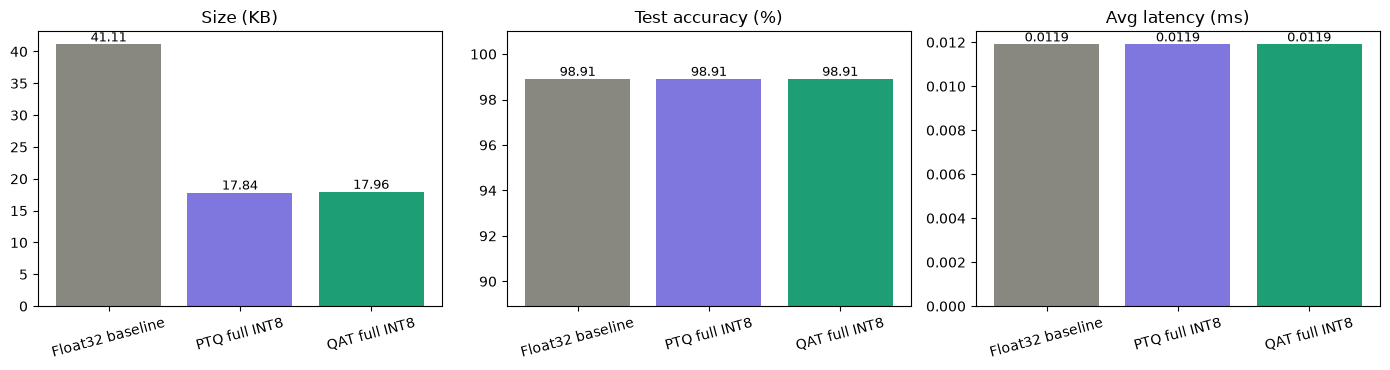

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
colors = ["#888780", "#7F77DD", "#1D9E75"]
for a, col in zip(ax, results.columns):
    bars = a.bar(results.index, results[col], color=colors)
    a.set_title(col); a.tick_params(axis="x", rotation=15)
    a.bar_label(bars, fmt="%.4f" if "latency" in col else "%.2f", fontsize=9)
ax[1].set_ylim(max(0, results["Test accuracy (%)"].min() - 10), 101)
plt.tight_layout(); plt.show()

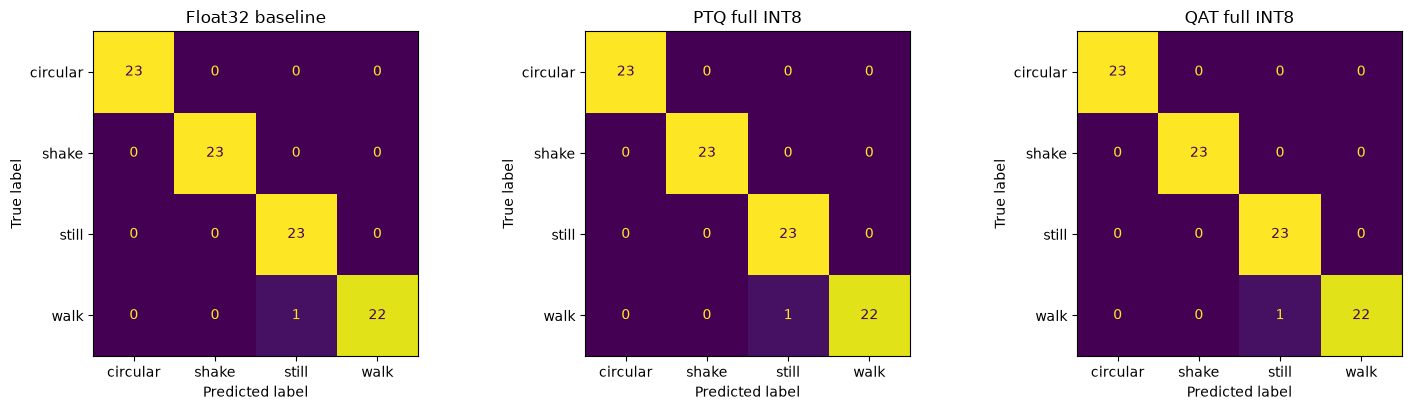

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, (name, path) in zip(ax, models.items()):
    cm = confusion_matrix(y_test, tflite_predict(path, X_test))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=a, colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

## 8. Questions

Q1. Why does Post-Training Quantization reduce model accuracy?
PTQ maps float32 weights and activations to 256 INT8 levels after training is finished. Every value is rounded to its nearest level and values outside the calibrated range are clipped. The model never saw this rounding during training, so the small errors add up layer by layer and can shift predictions. The calibration range also comes from only a small representative sample, which may not cover all real inputs.

Q2. What does QAT simulate during training, and how does this help the model?
QAT inserts fake-quantization nodes that quantize and dequantize weights and activations to INT8 in the forward pass, while gradients still flow in float32 (straight-through estimator). The loss therefore includes the quantization error, and the weights are adjusted to values that still work after rounding. QAT also learns the min/max range of each activation during training, so the INT8 model behaves almost the same as the trained model.

Q3. Was a representative dataset required to convert the QAT model? Justify your answer.
No. The QAT model already contains the learned quantization ranges (scales and zero points) for every weight and activation in its fake-quant nodes, so the converter does not need to calibrate anything. Section 6 shows that converting with and without a representative dataset gives a full INT8 model with the same size and accuracy. A representative dataset is only needed for PTQ, where ranges are unknown.

Q4. Did QAT change the size of the INT8 model? Explain.
No, apart from a negligible difference (a few hundred bytes, see the table). Size depends on the number of parameters and the bit width, and the PTQ and QAT models have the same architecture with every weight stored as 1 byte (biases as int32). QAT only changes the values of the weights and the quantization parameters, not how many there are. Both INT8 models are smaller than float32 by the same factor: the 9,188 weights shrink 4× (about 36 KB → 9 KB), but a model this small also stores a fixed amount of graph structure and quantization metadata, so the whole file shrinks by about 2.3× rather than the full 4×.

Q5. Under what conditions is PTQ sufficient, so that QAT is not needed?
PTQ is enough when the accuracy drop after INT8 conversion is within the acceptable limit for the application. This is usually the case for over-parameterised models, simple tasks with well-separated classes (like this one), models without very sensitive layers, and when a good representative dataset is available. QAT is worth the extra training time mainly for compact models such as MobileNet, depthwise-separable networks, or tasks where every bit of accuracy matters.

## 9. Result

In [ ]:
r = results
fp, ptq, qat = r.loc["Float32 baseline"], r.loc["PTQ full INT8"], r.loc["QAT full INT8"]
print(f"Float32 baseline : {fp['Size (KB)']:.2f} KB, {fp['Test accuracy (%)']:.2f}%, {fp['Avg latency (ms)']:.4f} ms")
print(f"PTQ full INT8    : {ptq['Size (KB)']:.2f} KB, {ptq['Test accuracy (%)']:.2f}%, {ptq['Avg latency (ms)']:.4f} ms")
print(f"QAT full INT8    : {qat['Size (KB)']:.2f} KB, {qat['Test accuracy (%)']:.2f}%, {qat['Avg latency (ms)']:.4f} ms")
print()
print(f"Both INT8 models are {fp['Size (KB)']/ptq['Size (KB)']:.1f}x smaller than the float32 model.")
print(f"PTQ changed accuracy by {ptq['Test accuracy (%)']-fp['Test accuracy (%)']:+.2f} points; "
      f"QAT changed it by {qat['Test accuracy (%)']-fp['Test accuracy (%)']:+.2f} points versus float32.")
print(f"QAT vs PTQ: {qat['Test accuracy (%)']-ptq['Test accuracy (%)']:+.2f} points.")

Float32 baseline : 41.11 KB, 98.91%, 0.0119 ms
PTQ full INT8    : 17.84 KB, 98.91%, 0.0119 ms
QAT full INT8    : 17.96 KB, 98.91%, 0.0119 ms

Both INT8 models are 2.3x smaller than the float32 model.
PTQ changed accuracy by +0.00 points; QAT changed it by +0.00 points versus float32.
QAT vs PTQ: +0.00 points.


**Conclusion:** full INT8 quantization reduced the model from about 41 KB (float32) to about 18 KB with both PTQ and QAT, a 2.3× reduction, and the two INT8 models are practically the same size. The four motion classes are well separated, so PTQ already kept the test accuracy at the float32 level (98.91%), and QAT matched it while needing no representative dataset at conversion. For this small, easy task PTQ is therefore sufficient and QAT brings no extra benefit; QAT is mainly worth its extra training when PTQ causes a noticeable accuracy drop, for example in compact image models such as MobileNetV2. Latency was about 0.012 ms for all three models on a laptop CPU (Apple Silicon): the model is so small that interpreter overhead dominates the arithmetic, and the CPU's optimised float kernels are already very fast. On microcontrollers without a floating-point unit, INT8 inference is significantly faster and uses less memory than float32.

## 10. Deliverables

In [ ]:
for f in ["baseline_fp32.tflite", "ptq_int8.tflite", "qat_int8.tflite"]:
    print(f"{f:22s} {size_kb(f):8.2f} KB")



baseline_fp32.tflite      41.11 KB
ptq_int8.tflite           17.84 KB
qat_int8.tflite           17.96 KB
